In [9]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Activation, Dropout, Flatten, Dense, Input, Layer
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape, concatenate, Bidirectional
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

In [10]:
import pandas as pd
image_path='Images'
data=pd.read_csv("captions.txt")
data.head()


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


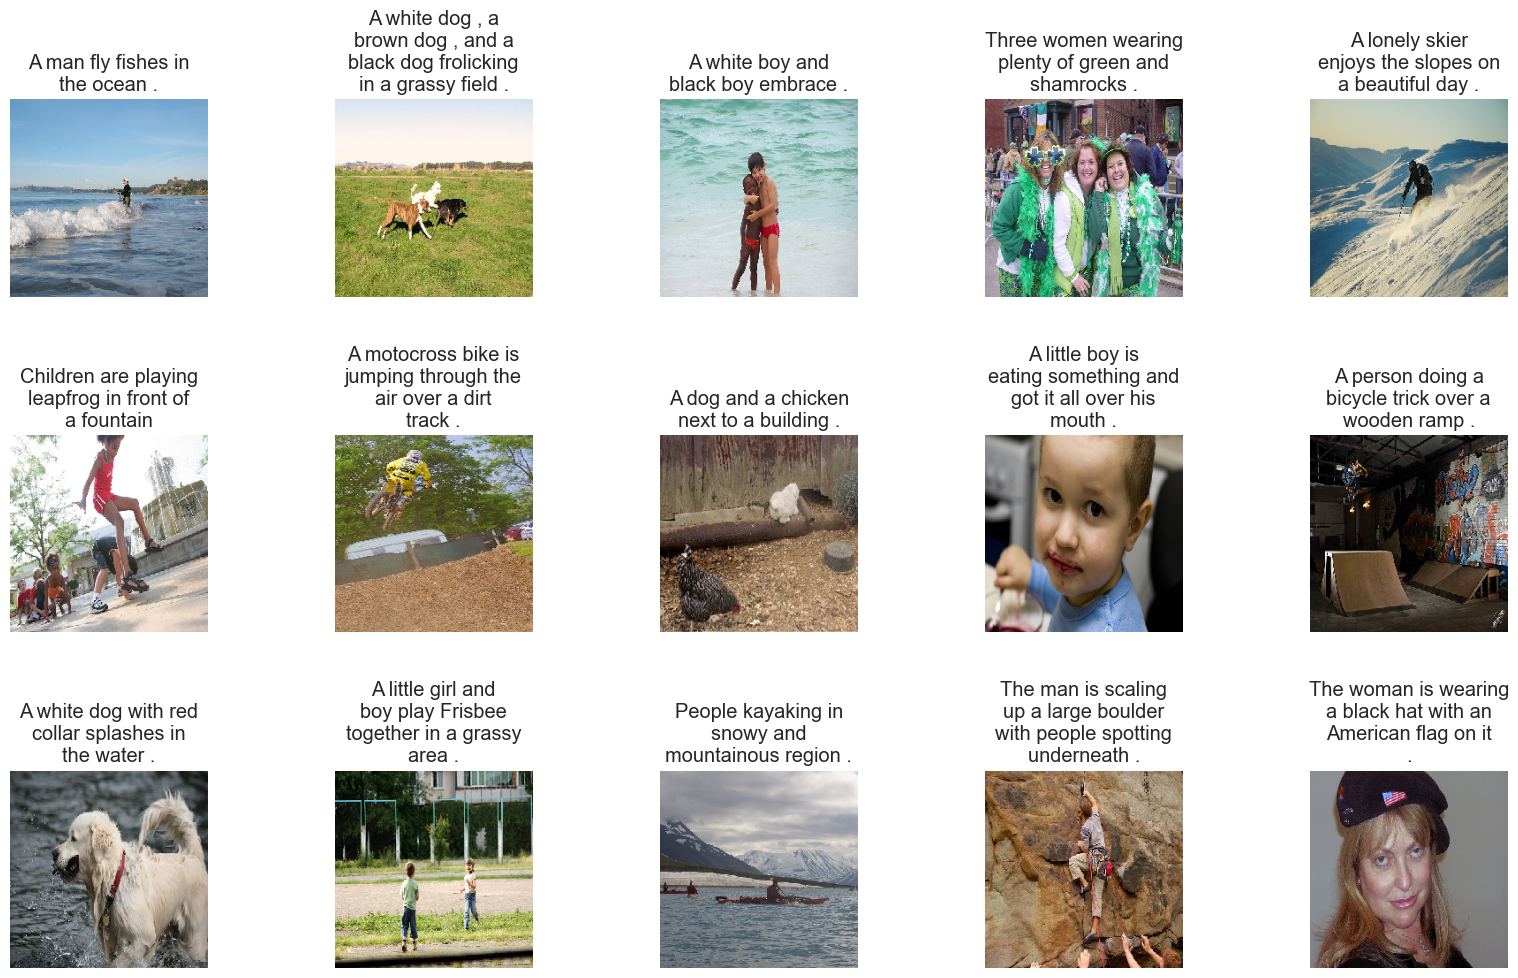

In [11]:
import matplotlib.pyplot as plt
import os
from textwrap import wrap
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def readImage(path, img_size=224):
    """Load and preprocess an image."""
    img = load_img(path, color_mode='rgb', target_size=(img_size, img_size))
    img = img_to_array(img)
    img = img / 255.0  # Normalize
    return img

def display_images(temp_df, image_path='Images'):
    """Display 15 sample images with captions."""
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(20, 20))
    
    for i in range(min(15, len(temp_df))):  # Ensure we don't exceed available images
        plt.subplot(5, 5, i+1)
        plt.subplots_adjust(hspace=0.7, wspace=0.3)
        
        # ✅ Fix column name (Change 'images' to the correct column in your DataFrame)
        img_file = temp_df['image'].iloc[i]  # Use the correct column name
        img_path = os.path.join(image_path, img_file)
        
        if os.path.exists(img_path):
            images = readImage(img_path)
            plt.imshow(images)
            plt.title("\n".join(wrap(temp_df['caption'].iloc[i], 20)))  # Fix caption access
            plt.axis("off")
        else:
            print(f"❌ Image not found: {img_path}")  # Debugging

# ✅ Ensure 'image' and 'caption' are correct column names in your DataFrame
display_images(data.sample(15), image_path='Images')


In [12]:
def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].apply(lambda x: x.replace("[^A-Za-z]",""))
    data['caption'] = data['caption'].apply(lambda x: x.replace("\s+"," "))
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word)>1]))
    data['caption'] = "startseq "+data['caption']+" endseq"

    return data 
    
data = text_preprocessing(data)

captions = data['caption'].tolist()

captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri-colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[1, 18, 315, 63, 195, 116, 2]

In [15]:
model = DenseNet201()
fe = Model(inputs=model.input, outputs=model.layers[-2].output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img,axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature


00%|██████████████████████████████████████████████████████████████████████████████| 8091/8091 [25:32<00:00,  5.28it/s]

In [14]:
class CustomDataGenerator(Sequence):
    
    def __init__(self, df, X_col, y_col, batch_size, directory, tokenizer, 
                 vocab_size, max_length, features,shuffle=True):
    
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.features = features
        self.shuffle = shuffle
        self.n = len(self.df)
        
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    
    def __len__(self):
        return self.n // self.batch_size
    
    def __getitem__(self,index):
    
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size,:]
        X1, X2, y = self.__get_data(batch)        
        return (X1, X2), y
    
    def __get_data(self,batch):
        
        X1, X2, y = list(), list(), list()
        
        images = batch[self.X_col].tolist()
           
        for image in images:
            feature = self.features[image][0]
            
            captions = batch.loc[batch[self.X_col]==image, self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1,len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)
            
        X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                
        return X1, X2, y


train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=64,directory=image_path,
                                      tokenizer=tokenizer,vocab_size=vocab_size,max_length=max_length,features=features)

NameError: name 'features' is not defined

In [8]:
train_generator[0]

((array([[7.8687946e-05, 7.3524076e-04, 1.1395995e-03, ..., 5.6523436e-01,
          2.2903755e-01, 6.9639885e-01],
         [7.8687946e-05, 7.3524076e-04, 1.1395995e-03, ..., 5.6523436e-01,
          2.2903755e-01, 6.9639885e-01],
         [7.8687946e-05, 7.3524076e-04, 1.1395995e-03, ..., 5.6523436e-01,
          2.2903755e-01, 6.9639885e-01],
         ...,
         [1.9476049e-04, 7.0213014e-04, 1.4947483e-03, ..., 2.7233697e-02,
          5.5759436e-01, 3.8916597e-01],
         [1.9476049e-04, 7.0213014e-04, 1.4947483e-03, ..., 2.7233697e-02,
          5.5759436e-01, 3.8916597e-01],
         [1.9476049e-04, 7.0213014e-04, 1.4947483e-03, ..., 2.7233697e-02,
          5.5759436e-01, 3.8916597e-01]], dtype=float32),
  array([[  0,   0,   0, ...,   0,   0,   1],
         [  0,   0,   0, ...,   0,   1,  42],
         [  0,   0,   0, ...,   1,  42,   3],
         ...,
         [  0,   0,   0, ...,  10,  76,  49],
         [  0,   0,   0, ...,  76,  49,   4],
         [  0,   0,   0, ...,

In [9]:
from tensorflow.keras.utils import plot_model

input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256), input_shape=(256,))(img_features)

sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped,sentence_features],axis=1)
sentence_features = LSTM(256)(merged)
x = Dropout(0.5)(sentence_features)
x = add([x, img_features])
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocab_size, activation='softmax')(x)

caption_model = Model(inputs=[input1,input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy',optimizer='adam')


from tensorflow.keras.callbacks import ModelCheckpoint

# Define the model checkpoint
model_name = "model.keras"  # Update the extension to .keras
checkpoint = ModelCheckpoint(
    model_name,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=3, 
                                            verbose=1, 
                                            factor=0.2, 
                                            min_lr=0.00000001)




history = caption_model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/50

Epoch 1: val_loss improved from inf to 4.27692, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 238s 437ms/step - loss: 5.6696 - val_loss: 4.2769 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 4.27692 to 3.95641, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 227s 423ms/step - loss: 4.3216 - val_loss: 3.9564 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 3.95641 to 3.82009, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 227s 423ms/step - loss: 4.0011 - val_loss: 3.8201 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 3.82009 to 3.72377, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 229s 426ms/step - loss: 3.8275 - val_loss: 3.7238 - learning_rate: 0.0010
Epoch 5/50

Epoch 5: val_loss improved from 3.72377 to 3.68566, saving model to model.keras
537/537 ━━━━━━━━━━━━━━━━━━━━ 229s 426ms/step - loss: 3.6864 - val_loss: 3.6857 - learning_rate: 0.0010
Epoch 6/50

Epoch 6: val_loss

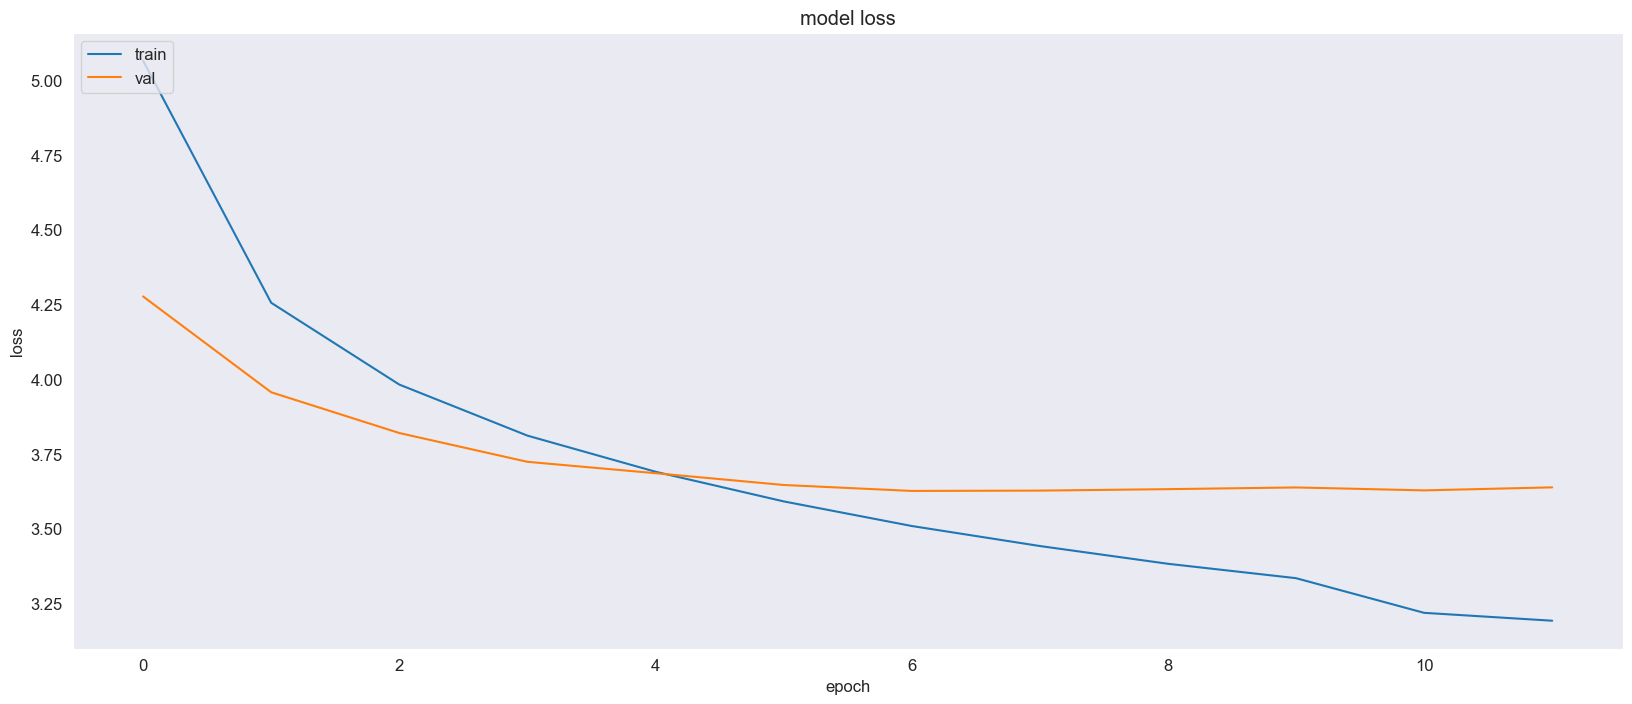

In [10]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [11]:
import pickle

# Save the tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save the feature extractor model
fe.save("feature_extractor.keras")

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import pickle

# load save files
model_path = "model.keras"
tokenizer_path = "tokenizer.pkl"
feature_extractor_path = "feature_extractor.keras"


def generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path, max_length=34, img_size=224):
    # Load the trained models and tokenizer
    caption_model = load_model(model_path)
    feature_extractor = load_model(feature_extractor_path)

    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)

    # Preprocess the image
    img = load_img(image_path, target_size=(img_size, img_size))
    img = img_to_array(img) / 255.0  # Normalize pixel values
    img = np.expand_dims(img, axis=0)
    image_features = feature_extractor.predict(img, verbose=0)  # Extract image features
    
    # Generate the caption
    in_text = "startseq"
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = caption_model.predict([image_features, sequence], verbose=0)
        yhat_index = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat_index, None)
        if word is None:
            break
        in_text += " " + word
        if word == "endseq":
            break
    caption = in_text.replace("startseq", "").replace("endseq", "").strip()

    # Display the image with the generated caption
    img = load_img(image_path, target_size=(img_size, img_size))
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=16, color='blue')
    plt.show()



def calculate_bleu(data, image_path, model, tokenizer, feature_extractor, max_length=34):
    actual, predicted = list(), list()
    for img_file in tqdm(data['image'].unique()):
        img_captions = data[data['image'] == img_file]['caption'].tolist()
        img_path = os.path.join(image_path, img_file)
        y_pred = generate_caption(img_path, model, tokenizer, feature_extractor, max_length)
        actual_captions = [caption.split() for caption in img_captions]
        predicted_caption = y_pred.split()
        actual.append(actual_captions)
        predicted.append(predicted_caption)

    bleu_1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
    bleu_2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
    bleu_3 = corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0))
    bleu_4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    
    return bleu_1, bleu_2, bleu_3, bleu_4

# Calculate BLEU scores on the test set
images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)
bleu_1, bleu_2, bleu_3, bleu_4 = calculate_bleu(test, image_path, caption_model, tokenizer, feature_extractor)


print(f"BLEU-1: {bleu_1}")
print(f"BLEU-2: {bleu_2}")
print(f"BLEU-3: {bleu_3}")
print(f"BLEU-4: {bleu_4}")


NameError: name 'caption_model' is not defined

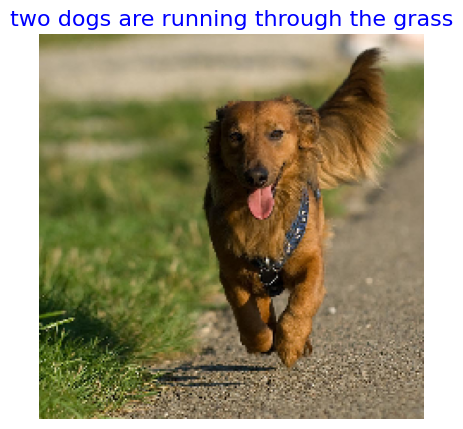

In [2]:
image_path = "Images/1089181217_ee1167f7af.jpg"  # Replace with the path to the input image
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

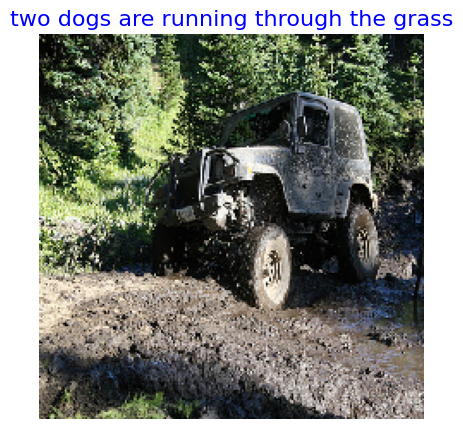

In [6]:
# Example usage
image_path = "Images/211277478_7d43aaee09.jpg"  # Replace with the path to the input image
generate_and_display_caption(image_path, model_path, tokenizer_path, feature_extractor_path)

In [7]:
import pandas as pd
image_path='Images'
data=pd.read_csv("captions.txt")

def calculate_bleu(data, image_path, model, tokenizer, feature_extractor, max_length=34):
    actual, predicted = list(), list()
    for img_file in tqdm(data['image'].unique()):
        img_captions = data[data['image'] == img_file]['caption'].tolist()
        img_path = os.path.join(image_path, img_file)
        y_pred = generate_caption(img_path, model, tokenizer, feature_extractor, max_length)
        actual_captions = [caption.split() for caption in img_captions]
        predicted_caption = y_pred.split()
        actual.append(actual_captions)
        predicted.append(predicted_caption)

    bleu_1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
    bleu_2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
    bleu_3 = corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0))
    bleu_4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    
    return bleu_1, bleu_2, bleu_3, bleu_4

# Calculate BLEU scores on the test set
images = data['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)
bleu_1, bleu_2, bleu_3, bleu_4 = calculate_bleu(test, image_path, caption_model, tokenizer, feature_extractor)


print(f"BLEU-1: {bleu_1}")
print(f"BLEU-2: {bleu_2}")
print(f"BLEU-3: {bleu_3}")
print(f"BLEU-4: {bleu_4}")


NameError: name 'caption_model' is not defined